# Exercise 1: Conceptual Questions

### 1. Anchor Boxes:
Anchor boxes are predefined bounding box shapes. Instead of predicting box shapes from scratch,
the model adjusts these predefined boxes. This makes learning faster and more stable.
Each anchor box specializes in detecting objects of certain shapes (e.g., tall or wide objects).

### 2. NMS Threshold:
If the IoU threshold is very high (e.g., 0.9), many overlapping boxes will remain, causing duplicates.
If the threshold is very low (e.g., 0.1), too many boxes will be removed, possibly losing correct detections.

### 3. Single Shot Trade-off:
YOLO is a single-shot detector, meaning it predicts everything in one pass.
Two-stage detectors (like Faster R-CNN) first propose regions and then refine them.
Because YOLO skips the refinement step, it is faster but less accurate, especially for small objects.

# Exercise 2: Object Detection on an Image with YOLO

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

with open("coco.names", "r") as f:
    classes = [line.strip() for line in f.readlines()]

net = cv2.dnn.readNet("yolov3.weights", "yolov3.cfg")

image = cv2.imread("image.jpg")

if image is None:
    print("Error: image.jpg not found")

height, width = image.shape[:2]

In [4]:
blob = cv2.dnn.blobFromImage(image, 1/255.0, (416, 416), swapRB=True, crop=False)

net.setInput(blob)
output_layer_names = net.getUnconnectedOutLayersNames()
layer_outputs = net.forward(output_layer_names)

In [5]:
boxes = []
confidences = []
class_ids = []

for output in layer_outputs:
    for detection in output:
        scores = detection[5:]
        class_id = np.argmax(scores)
        confidence = scores[class_id]

        if confidence > 0.5:
            center_x = int(detection[0] * width)
            center_y = int(detection[1] * height)
            w = int(detection[2] * width)
            h = int(detection[3] * height)

            x = int(center_x - w / 2)
            y = int(center_y - h / 2)

            boxes.append([x, y, w, h])
            confidences.append(float(confidence))
            class_ids.append(class_id)

In [6]:
indexes = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)

(np.float64(-0.5), np.float64(999.5), np.float64(666.5), np.float64(-0.5))

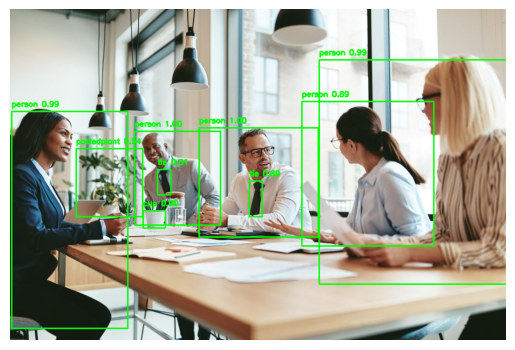

In [7]:
for i in indexes.flatten():
    x, y, w, h = boxes[i]
    label = classes[class_ids[i]]
    confidence = confidences[i]

    cv2.rectangle(image, (x, y), (x+w, y+h), (0,255,0), 2)
    cv2.putText(image, f"{label} {confidence:.2f}", (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.axis("off")

# Exercise 3: Challenge Problem - Real-Time Webcam Detection

In [2]:
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()

    if not ret or frame is None:
        print("Camera not working")
        break

    blob = cv2.dnn.blobFromImage(frame, 1/255.0, (416,416), swapRB=True, crop=False)
    net.setInput(blob)

    outputs = net.forward(net.getUnconnectedOutLayersNames())

    cv2.imshow("YOLO", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Camera not working


# Exercise 4: Try the latest version! 

In [7]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model("image.jpg")

results[0].show()


image 1/1 C:\Users\Lusin\Downloads\M8_S5\image.jpg: 448x640 5 persons, 1 tie, 1 bottle, 1 cup, 1 chair, 1 potted plant, 1 dining table, 395.3ms
Speed: 98.0ms preprocess, 395.3ms inference, 64.1ms postprocess per image at shape (1, 3, 448, 640)


### COMPARISON ANSWER

YOLOv8 performs better than YOLOv3 in both accuracy and detection quality.
It detects smaller objects more reliably and produces fewer false positives.

In terms of speed:
- YOLOv8 is optimized and can be faster on GPU
- On CPU, performance may be similar or slightly slower

The improvement is due to:
- Better architecture
- Improved training methods
- More efficient feature extraction